In [106]:
# creating my own graident descent class

In [136]:
import numpy as np
from sklearn.datasets import make_regression

In [137]:
X, y = make_regression(n_samples= 100, n_features= 1, n_informative= 1, noise = 30,n_targets= 1, random_state= 20)

In [139]:
import matplotlib.pyplot as plt

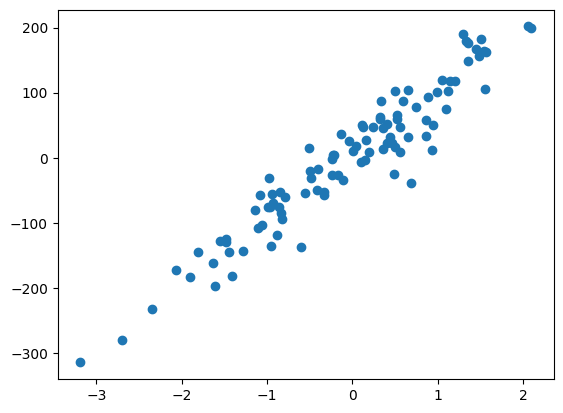

In [140]:
plt.scatter(X, y)

In [141]:
from sklearn.model_selection import train_test_split

In [142]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 20)

In [143]:
# first creating a normal linear regression
from sklearn.linear_model import LinearRegression

In [144]:
lr = LinearRegression()

In [145]:
lr.fit(X, y)

LinearRegression()

In [146]:
lr.coef_

array([96.223159])

In [147]:
lr.intercept_

np.float64(3.436945885374053)

In [148]:
y_pred = lr.predict(X_test)

In [149]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.9163296113139717

In [150]:
from numpy.random import random_integers
# now creating our own class to find only intercept as
class GdRegressor:

  def __init__(self, learning_rate, epochs, intercept, slope):
    self.lr = learning_rate
    self.epochs = epochs
    self.b = intercept
    self.m = slope

  def descent(self, X, y):
    for i in range(self.epochs):
      loss_slope_b = -2 * np.sum(y - (self.m * X.ravel()) - self.b)
      self.b = self.b - (loss_slope_b * self.lr)
      #print(loss_slope_b, self.b)
      loss_slope_m = -2 * np.sum((y - (self.m * X.ravel()) - self.b) * X.ravel())
      self.m = self.m - (loss_slope_m * self.lr)
      #print(loss_slope_m, self.m)
    print(self.b)
    print(self.m)

  def predict(self, X):
    return ((self.m * X) + self.b)

In [151]:
gd_reg = GdRegressor(0.001, 30, 0, 1)

In [152]:
gd_reg.descent(X, y)

3.4029018602068897
96.18177806095125


In [153]:
# like this we can create our own gradient descent class and play with learning_rate, initial value, epochs etc

In [155]:
gd_y_pred = gd_reg.predict(X_test)

In [156]:
r2_score(y_test, gd_y_pred)

0.9163174382817504